In [61]:
import pubchempy as pcp
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd 

Pubchem is a useful database for molecular information

for example, Caffeine: 

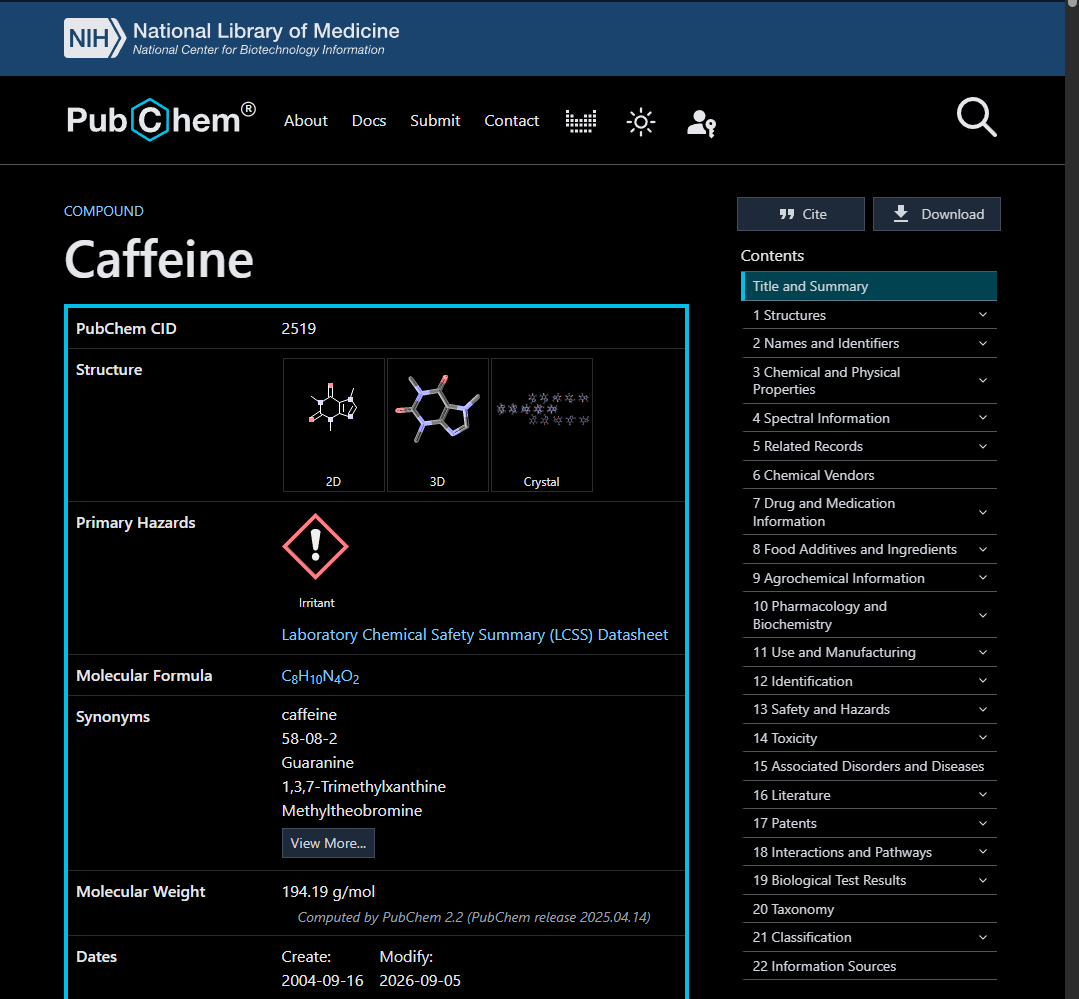





with pubchempy, we can use the package as wrapper around the API service that pubchem provided so we dont have to search each compound one by one

documetation here: https://docs.pubchempy.org/en/latest/

here are a few ways you might use it:

for example, if you know the cid of the compound, you may just use cid (which is a unique id for each compound in the database)

In [62]:
caffeine = pcp.Compound.from_cid(2519)
print(caffeine.smiles)
print(caffeine.molecular_formula)
print(caffeine.synonyms)


CN1C=NC2=C1C(=O)N(C(=O)N2C)C
C8H10N4O2
['caffeine', '58-08-2', 'Guaranine', '1,3,7-Trimethylxanthine', 'Methyltheobromine', 'Theine', 'Thein', 'Cafeina', 'Caffein', 'Cafipel', 'Koffein', 'Mateina', 'Alert-pep', 'Coffeine', 'Anhydrous caffeine', "Refresh'n", 'Caffedrine', 'Vivarin', 'Stim', 'No-Doz', 'Cafamil', 'Cafecon', 'Caffine', 'Dexitac', 'Nodaca', '7-Methyltheophylline', 'Eldiatric C', 'Durvitan', 'Hycomine', 'Organex', 'Nix Nap', 'Methyltheobromide', 'Coffeinum', 'Coffein', '3,7-Dihydro-1,3,7-trimethyl-1H-purine-2,6-dione', 'Tirend', '1,3,7-Trimethylpurine-2,6-dione', '1,3,7-Trimethyl-2,6-dioxopurine', 'Tri-Aqua', 'Kofein', 'Caffeine, anhydrous', '1-methyltheobromine', '1H-Purine-2,6-dione, 3,7-dihydro-1,3,7-trimethyl-', 'CAFFEINE ANHYDROUS', 'Methylxanthine theophylline', 'teina', 'Caffeina', '1,3,7-Trimethyl-3,7-dihydro-1H-purine-2,6-dione', 'NCI-C02733', '1,3,7-trimethyl-2,3,6,7-tetrahydro-1H-purine-2,6-dione', 'FEMA No. 2224', 'cafeine', 'Caffeinum', 'DTXSID0020232', '1,3,7-t

or, in most cases, we dont know the cid at all, but we have the name, then we can try to search it

In [63]:
caffeine = pcp.get_compounds("caffeine", "name")[0]
print(caffeine.cid)
print(caffeine.smiles)
print(caffeine.molecular_formula)
print(caffeine.synonyms)

2519
CN1C=NC2=C1C(=O)N(C(=O)N2C)C
C8H10N4O2
['caffeine', '58-08-2', 'Guaranine', '1,3,7-Trimethylxanthine', 'Methyltheobromine', 'Theine', 'Thein', 'Cafeina', 'Caffein', 'Cafipel', 'Koffein', 'Mateina', 'Alert-pep', 'Coffeine', 'Anhydrous caffeine', "Refresh'n", 'Caffedrine', 'Vivarin', 'Stim', 'No-Doz', 'Cafamil', 'Cafecon', 'Caffine', 'Dexitac', 'Nodaca', '7-Methyltheophylline', 'Eldiatric C', 'Durvitan', 'Hycomine', 'Organex', 'Nix Nap', 'Methyltheobromide', 'Coffeinum', 'Coffein', '3,7-Dihydro-1,3,7-trimethyl-1H-purine-2,6-dione', 'Tirend', '1,3,7-Trimethylpurine-2,6-dione', '1,3,7-Trimethyl-2,6-dioxopurine', 'Tri-Aqua', 'Kofein', 'Caffeine, anhydrous', '1-methyltheobromine', '1H-Purine-2,6-dione, 3,7-dihydro-1,3,7-trimethyl-', 'CAFFEINE ANHYDROUS', 'Methylxanthine theophylline', 'teina', 'Caffeina', '1,3,7-Trimethyl-3,7-dihydro-1H-purine-2,6-dione', 'NCI-C02733', '1,3,7-trimethyl-2,3,6,7-tetrahydro-1H-purine-2,6-dione', 'FEMA No. 2224', 'cafeine', 'Caffeinum', 'DTXSID0020232', '1,

note that if you search by name or smiles, you get a list instead (since there can be multiple matches)

for example:


In [64]:
cids = pcp.get_cids("2-nonenal", "name", "substance", list_return="flat")
results = [pcp.Compound.from_cid(cid) for cid in cids]
print(results)

for r in results:
    print(r.iupac_name)

[Compound(17166), Compound(5283335), Compound(5354833)]
non-2-enal
(E)-non-2-enal
(Z)-non-2-enal


-------------------------

rdkit is another useful tool, although it's a lot more complicated which contains lots of tools a random stuff for computational uses...


anyways, we're only using this for checking a molecule, so that means, we know the structure of the compound we want

and thus, there must be a SMILES for that compound 

this is the basic stuff we need at the first place before constructing the compound, which you may get from pubchem or you can use other tools like chemdraw to draw the compound if you dont know what it is.


lets take caffeine again as example:


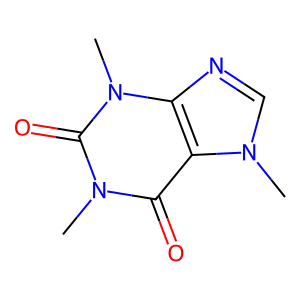

In [65]:
from rdkit import Chem
from rdkit.Chem import Draw

caffeine = Chem.MolFromSmiles("CN1C=NC2=C1C(=O)N(C(=O)N2C)C")
img = Draw.MolToImage(caffeine)
img

and here's caffeine! 

but wait, this doesnt do much other than showing you what you have. 


<Br>

a more useful thing is that, we can use rdkit to match substructures in a compound. 

lets say we're doing ESI negative mode and we want to know, from a list of compounds, does the compound has a specific group that might loss proton and thus detectable in negative mode.

for this purpose, instead of SMILES, we need to use SMARTS instead (which is another way to present a chemical structure)

SMARTS is useful for subgroup or functional groups matching. instead of writing it, you may find common ones from here: https://www.daylight.com/dayhtml_tutorials/languages/smarts/smarts_examples.html

for example, here are some compounds...

In [67]:

some_compound_cids = [2519, 8892, 750, 1183  ]
## these are caffeine, hexanoic acid, glycine, and vanillin


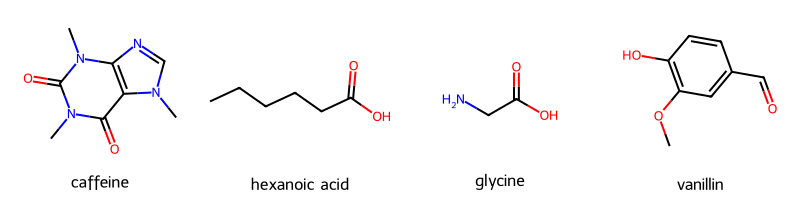

In [73]:
compounds = {}
mol_list = []
for c in some_compound_cids:
    result = {"cid":c}
    compound = pcp.Compound.from_cid(c)
    smiles = result["smiles"] = compound.smiles
    result["formula"] = compound.molecular_formula
    compounds[c] = result
    mol_list.append(Chem.MolFromSmiles(smiles))
img = Chem.Draw.MolsToGridImage(
    mol_list, 
    molsPerRow=4,          # Number of molecules per row in the grid
    subImgSize=(200, 200), # Pixel dimensions for each individual molecule image
    legends=["caffeine", "hexanoic acid", "glycine", "vanillin"]   # Labels to display under each molecule
)
img

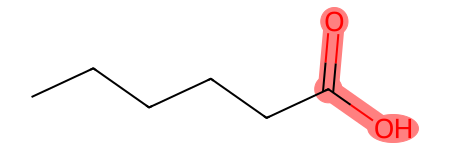

In [70]:
hexanoic_acid = mol_list[1]
for mol in mol_list:
    matches = hexanoic_acid.GetSubstructMatches(Chem.MolFromSmarts("[CX3](=O)[OX1H0-,OX2H1]"))
hexanoic_acid

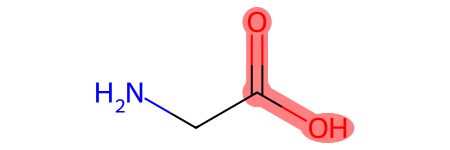

In [71]:
glycine = mol_list[2]
for mol in mol_list:
    matches = glycine.GetSubstructMatches(Chem.MolFromSmarts("[CX3](=O)[OX1H0-,OX2H1]"))
glycine

In [75]:
pattern_dict = {"Amine":"[NX3;H2,H1;!$(NC=O)]","Carboxylic acid":"[CX3](=O)[OX1H0-,OX2H1]",
                "Phenol": "[OX2H][$(C=C),$(cc)]"}
match_results = {}
names =["caffeine", "hexanoic acid", "glycine", "vanillin"]

for i, molecule in enumerate(mol_list):
    res = {}
    for f in pattern_dict:
        match = len(molecule.GetSubstructMatches(Chem.MolFromSmarts(pattern_dict[f])))
        res[f] = int(match)
    match_results[names[i]] = res


match_df = pd.DataFrame(match_results)
match_df

,caffeine,hexanoic acid,glycine,vanillin
Amine,0,0,1,0
Carboxylic acid,0,1,1,0
Phenol,0,0,0,1


--------------------------

we can also try to do chemical reaction and make new compound, which is usually require writing a reaction template with SMARTS

for example, tosyl chloride can be expressed as in SMILES or in SMARTS as shown below




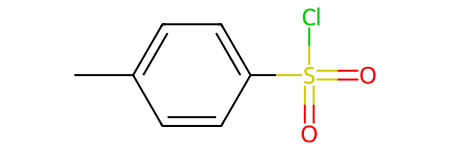

In [2]:
ts_cl = Chem.MolFromSmiles("C1(=CC=C(C=C1)C)[S](=O)(=O)Cl")
ts_cl

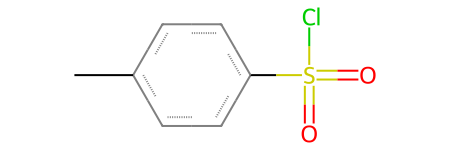

In [5]:
ts_cl_2 = Chem.MolFromSmarts("c1(ccc(cc1)-[#6])-[#16](=[#8])(=[#8])-[Cl]")
ts_cl_2

and lets say we have our substrate glycine which has an amine and an acid group

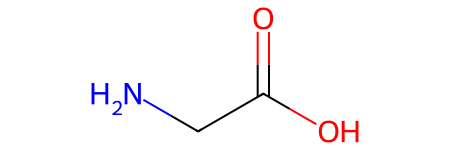

In [6]:
glycine = Chem.MolFromSmiles("C(C(=O)O)N")
glycine

in general, SMARTS reaction goes like 

`[reactant1] . [reactant2] >> [product]`


which we can also specify the atom number which tell where to make the connection

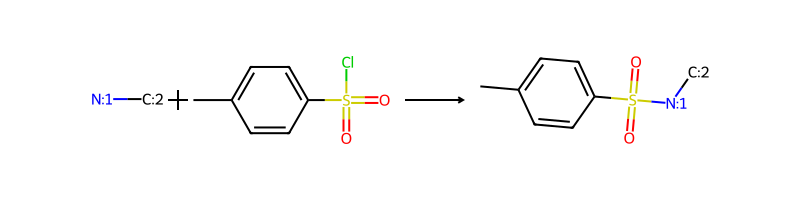

In [77]:
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D, ReactionToImage


torsyl_labeling_rxn = "[#6:2]-[#7:1].c1(ccc(cc1)-[#6])-[#16](=[#8])(=[#8])-[Cl]>>c1(ccc(cc1)-[#6])-[#16](=[#8])(=[#8])-[#7:1]-[#6:2]"
rxn = AllChem.ReactionFromSmarts(torsyl_labeling_rxn,useSmiles=True) # if you dont specify useSmiles the drawing will be based on SMARTS with the weird ring expression

ReactionToImage(rxn)

[10:44:33] reactant 1 has no mapped atoms.


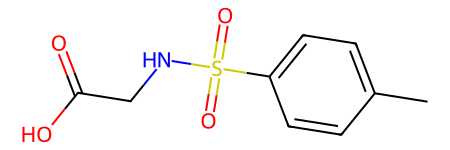

In [38]:
products  = rxn.RunReactants((glycine, ts_cl_2))
smiles = Chem.MolToSmiles(products[0][0],isomericSmiles=True) 
product_compound = Chem.MolFromSmiles(smiles)
product_compound


note the rdkit runs the reaction a bit different as it looks for symmetry in the compounds, which means it doesnt know if a bezene ring or the sulfonyl group's two side are the same

so instead of one single possible product, it returns four identifcal SMILES, which two comes from the benzene ring (counting from either direction) and two from the two oxygen on sulfonyl



In [36]:
for p in products:
    smiles = Chem.MolToSmiles(p[0],isomericSmiles=True) 
    print(smiles)

Cc1ccc(S(=O)(=O)NCC(=O)O)cc1
Cc1ccc(S(=O)(=O)NCC(=O)O)cc1
Cc1ccc(S(=O)(=O)NCC(=O)O)cc1
Cc1ccc(S(=O)(=O)NCC(=O)O)cc1


so, we usually just need to clean

In [45]:
product_smiles = set()
for p in products:
    smiles = Chem.MolToSmiles(p[0],isomericSmiles=True) 
    if not smiles in product_smiles:
        product_smiles.add(smiles)
product_smiles = list(product_smiles)
product_smiles

['Cc1ccc(S(=O)(=O)NCC(=O)O)cc1']

but wait, the amine can still undergo another reaction with TsCl...

so we can run this again...

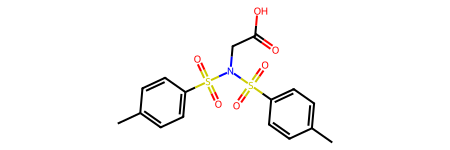

In [ ]:
ts_glycine = Chem.MolFromSmiles(product_smiles[0])

second_rxn_products  = rxn.RunReactants((ts_glycine, ts_cl_2))
final_product_smiles = set()
for p in second_rxn_products:
    smiles = Chem.MolToSmiles(p[0],isomericSmiles=True) 
    if not smiles in final_product_smiles:
        final_product_smiles.add(smiles)
final_product_smiles = list(final_product_smiles)

ts_ts_glycine = Chem.MolFromSmiles(final_product_smiles[0])
ts_ts_glycine

and it's useful to calculate the mass as well from SMILES, in case you run a whole bunch of compounds and you want to know the mass 

In [78]:
from rdkit.Chem import Descriptors

mass = Descriptors.ExactMolWt(ts_ts_glycine)
print(mass)


383.049729264


though, if you want to calculate the m/z instead, you can either do it with generating the charged compound, or you might just calucalte directly 

for example, we check if there's available amine in the compound to accept proton,

Cc1ccc(S(=O)(=O)[NH+](CC(=O)O)S(=O)(=O)c2ccc(C)cc2)cc1
384.05700571609


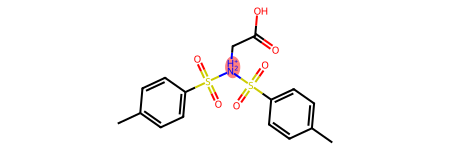

In [115]:
ts_ts_glycine = Chem.MolFromSmiles(final_product_smiles[0])

amine_pattern = Chem.MolFromSmarts("[NX3;!$(NC=O)]")
matches = ts_ts_glycine.GetSubstructMatches(amine_pattern)
amine_atom_idx = matches[0][0]
amine_atom = ts_ts_glycine.GetAtomWithIdx(amine_atom_idx)
amine_atom.SetFormalCharge(amine_atom.GetFormalCharge() + 1)
amine_atom.SetNumExplicitHs(amine_atom.GetTotalNumHs() + 1)
protonated_smiles = Chem.MolToSmiles(ts_ts_glycine)
print(protonated_smiles)
exact_mass = Descriptors.ExactMolWt(ts_ts_glycine)
print(exact_mass)
ts_ts_glycine


and note that will alternate on the original molecule you created, so each time you might want to create a new molecule from copying the smiles to make sure you dont touch the original one... 

or another safer way is to use SMARTS reaction instead to make new "product"


SMILES: Cc1ccc(S(=O)(=O)[NH+](CC(=O)O)S(=O)(=O)c2ccc(C)cc2)cc1
Mass: 384.05700571609003


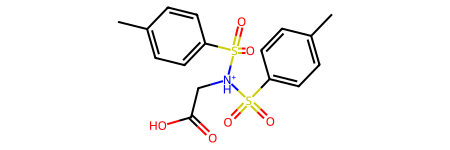

In [116]:
ts_ts_glycine = Chem.MolFromSmiles(final_product_smiles[0])

protonate_rxn = AllChem.ReactionFromSmarts(
    "[NX3;!$(NC=O):1]>>[N+1:1]"
)
products = protonate_rxn.RunReactants((ts_ts_glycine,))
protonated_mol = products[0][0]
print("SMILES:", Chem.MolToSmiles(protonated_mol))
print("Mass:", Descriptors.ExactMolWt(protonated_mol))
protonated_mol

or you might just calculate it yourself... 

a proton is basically hydrogen - an electron, thus 
1.00782503223- 0.000548580= 1.007276452 (mass of proton in Da)

In [106]:
ts_ts_glycine = Chem.MolFromSmiles(final_product_smiles[0])

m_plus_h = Descriptors.ExactMolWt(ts_ts_glycine) + 1.007276452
print(m_plus_h)

384.057005716
